In [1]:
import os
import pandas as pd
import numpy as np
import hds
from plt_rcs import *

In [2]:
plt.rc(group='figure', figsize=(12, 4))

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [4]:
os.chdir('../../data')

In [5]:
[i for i in os.listdir() if 'Won' in i][0]

'Won_Dollar_Exchange_Rage_20260324.pkl'

In [6]:
df = pd.read_pickle('Won_Dollar_Exchange_Rage_20260324.pkl')

In [7]:
df.columns = ['date', 'rate']

In [8]:
df.head()

,date,rate
0,2026.03.24,"1,493.00"
1,2026.03.23,"1,489.50"
2,2026.03.20,"1,506.50"
3,2026.03.19,"1,491.00"
4,2026.03.18,"1,505.00"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    550 non-null    object
 1   rate    550 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB


In [10]:
df['date'] = pd.to_datetime(arg=df['date'])

In [11]:
df['rate'] = df['rate'].str.replace(pat=',', repl='')

In [12]:
df.head()

,date,rate
0,2026-03-24,1493.00
1,2026-03-23,1489.50
2,2026-03-20,1506.50
3,2026-03-19,1491.00
4,2026-03-18,1505.00


In [13]:
df['rate'] = pd.to_numeric(arg=df['rate'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    550 non-null    datetime64[ns]
 1   rate    550 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.7 KB


In [15]:
std_date = '2026-01-01'

In [16]:
df = df.sort_values('date', ignore_index=True)

In [17]:
df = df.set_index('date')

In [18]:
df.head()

,rate
date,
2023-12-19,1304.0
2023-12-20,1304.0
2023-12-21,1300.0
2023-12-22,1303.0
2023-12-26,1297.0


In [19]:
full_idx = pd.date_range(df.index.min(), df.index.max())

In [20]:
df = df.reindex(full_idx)

In [21]:
df.index.name = 'date'

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 827 entries, 2023-12-19 to 2026-03-24
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rate    550 non-null    float64
dtypes: float64(1)
memory usage: 12.9 KB


In [23]:
df.head()

,rate
date,
2023-12-19,1304.0
2023-12-20,1304.0
2023-12-21,1300.0
2023-12-22,1303.0
2023-12-23,NaN


In [24]:
df['rate'] = df['rate'].ffill()

In [25]:
df.isna().sum()

rate    0
dtype: int64

In [26]:
df = df.reset_index().rename(columns={'date': 'ds', 'rate': 'y'})

In [27]:
df.head()

,ds,y
0,2023-12-19,1304.0
1,2023-12-20,1304.0
2,2023-12-21,1300.0
3,2023-12-22,1303.0
4,2023-12-23,1303.0


In [ ]:
train = df.loc[df['ds'].lt(std_date)]
test = df.loc[df['ds'].ge(std_date)]

In [29]:
display(train.tail())
display(test.head())

,ds,y
739,2025-12-27,1445.0
740,2025-12-28,1445.0
741,2025-12-29,1434.5
742,2025-12-30,1441.0
743,2025-12-31,1447.0


,ds,y
744,2026-01-01,1447.0
745,2026-01-02,1446.7
746,2026-01-03,1446.7
747,2026-01-04,1446.7
748,2026-01-05,1446.8


In [32]:
from prophet import Prophet

In [33]:
pp_basic = Prophet()

In [34]:
pp_basic.fit(train)

14:39:40 - cmdstanpy - INFO - Chain [1] start processing
14:39:40 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
n_test = len(test)

In [36]:
pp_basic_future = pp_basic.make_future_dataframe(n_test)

In [38]:
display(pp_basic_future.head())
display(pp_basic_future.tail())

,ds
0,2023-12-19
1,2023-12-20
2,2023-12-21
3,2023-12-22
4,2023-12-23


,ds
822,2026-03-20
823,2026-03-21
824,2026-03-22
825,2026-03-23
826,2026-03-24


In [39]:
pp_basic_yhat = pp_basic.predict(pp_basic_future)

In [40]:
pp_basic_pred = pp_basic_yhat.loc[test.index, 'yhat']

In [41]:
pp_basic_pred

744    1455.857365
745    1455.582325
746    1453.654349
747    1451.663611
748    1448.588269
          ...     
822    1321.576222
823    1321.224288
824    1320.906293
825    1319.583347
826    1320.981226
Name: yhat, Length: 83, dtype: float64

In [42]:
pp_basic_resid = test['y'] - pp_basic_pred

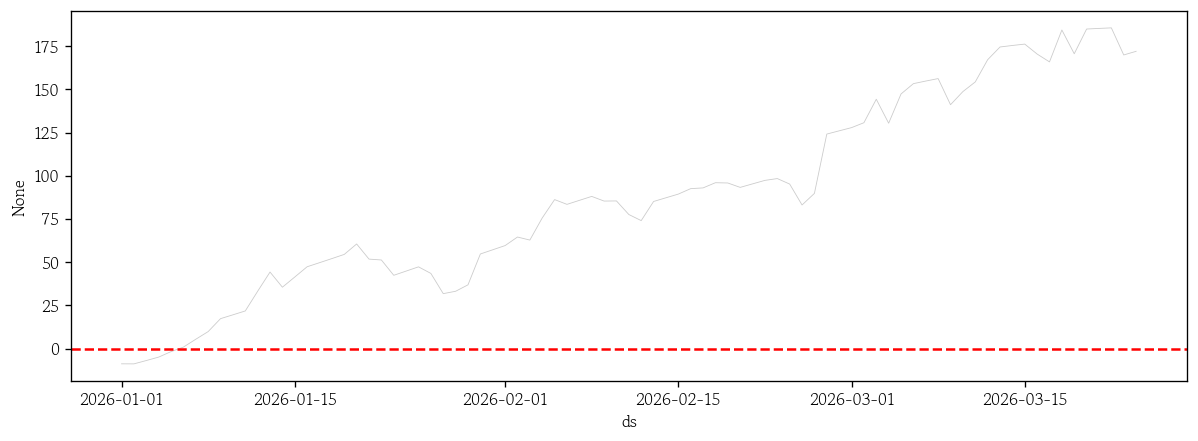

In [54]:
sns.lineplot(x=test['ds'], y=pp_basic_resid, color='0.8', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

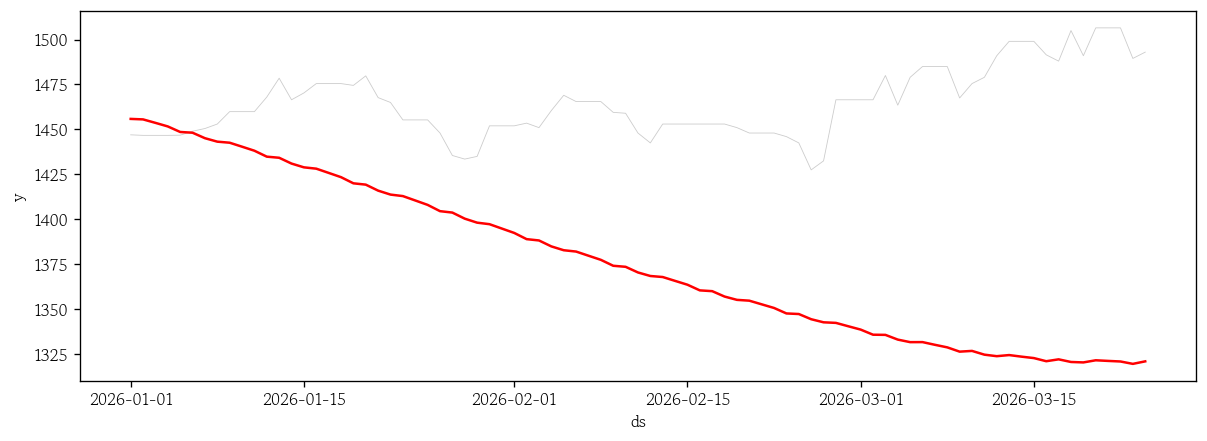

In [53]:
sns.lineplot(x=test['ds'], y=test['y'], color='0.8', linewidth=0.5)
sns.lineplot(x=test['ds'], y=pp_basic_pred, color='red');

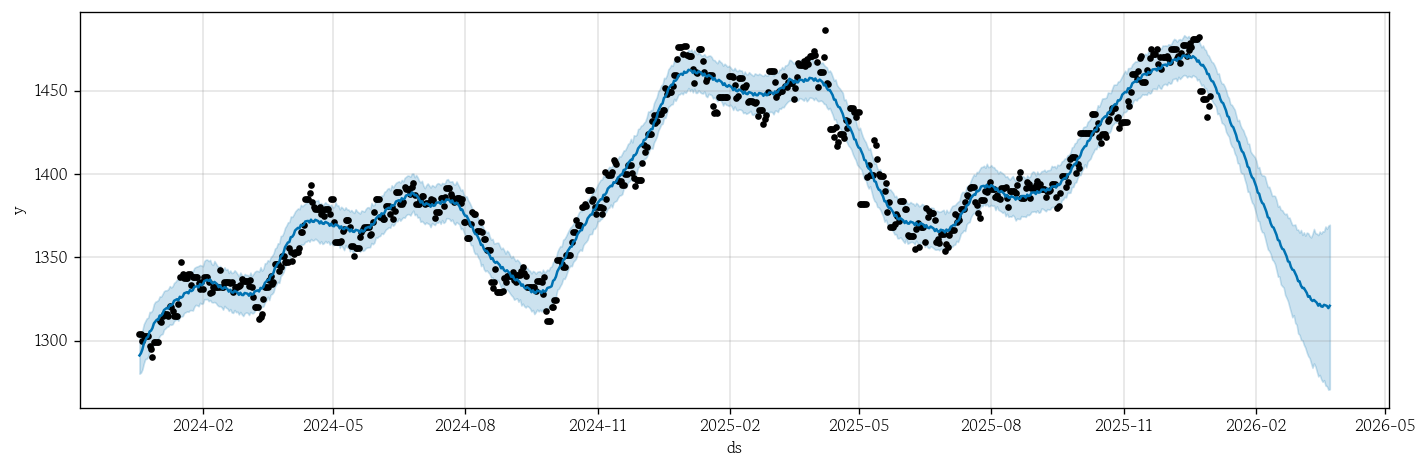

In [51]:
pp_basic.plot(pp_basic_yhat, figsize=(12, 4));

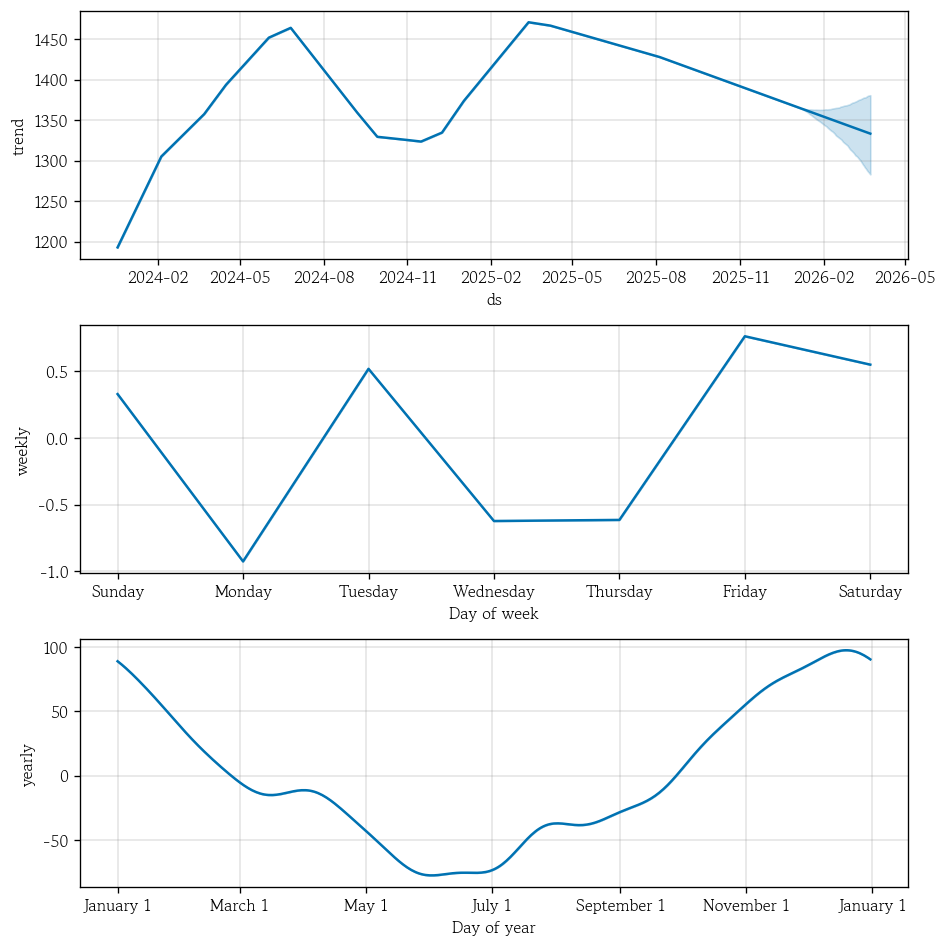

In [52]:
pp_basic.plot_components(pp_basic_yhat, figsize=(8, 8));

In [55]:
hds.stat.regmetrics(y_true=test['y'], y_pred=pp_basic_pred)

,metric,score,description
0,R^2,-29.328517,R Squared
1,MSE,10845.225524,Mean Squared Error
2,RMSE,104.140413,Root Mean Squared Error
3,MSLE,0.005465,Mean Squared Log Error
4,RMSLE,0.073924,Root Mean Squared Log Error
5,MAE,88.674557,Mean Absolute Error
6,MAPE,0.060205,Mean Absolute Percentage Error
